# Clustering (K-Prototypes)

This is part of the EDA to understand who is happy and who is not.

This notebook mirrors `99_clustering.ipynb` but uses **K-Prototypes** (from the `kmodes` library) instead of K-Means, so categorical features can be used directly without one-hot encoding.

In [22]:
from c08_farming_exit import config
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from kmodes.kprototypes import KPrototypes
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [25]:
df = pd.read_csv(config.PROCESSED_DATA_DIR / "features_data.csv")

In [27]:
#Feature List
X = [
    "personal_id",
    "female",
    "age",
    "years_of_schooling",
    "land_size_cropland_acres",

    "farm_empl_last_12_months",
    "empl_type",

    "hh_optimism_index",
    "worry_about_job_loss_or_economic_livelihood",
    "life_satisfaction",

    "aspiration_continue_farming",
    "child_aspiration_continue_farming",

    "main_decision_maker",

    "off_farm_hours_annual_share",
]

df = df[X]

In [28]:
len(df)

2974

In [29]:
df = df.dropna(subset=["off_farm_hours_annual_share"])

In [30]:
len(df)

2094

In [31]:
#Are you the main decision maker? Create dummy with 1 0 
df['main_decision_maker'] = (df['personal_id'] == df['main_decision_maker']).astype(int)
df = df.drop(columns=['personal_id'])

In [32]:
# Check all dtypes
df.dtypes

# Split into numerical and categorical
numerical_cols = ["child_aspiration_continue_farming", "life_satisfaction", "land_size_cropland_acres", "age", "years_of_schooling", "hh_optimism_index", "worry_about_job_loss_or_economic_livelihood", "off_farm_hours_annual_share",]
categorical_cols = ["farm_empl_last_12_months", 'empl_type', 'aspiration_continue_farming', "female", "main_decision_maker",]

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: ['child_aspiration_continue_farming', 'life_satisfaction', 'land_size_cropland_acres', 'age', 'years_of_schooling', 'hh_optimism_index', 'worry_about_job_loss_or_economic_livelihood', 'off_farm_hours_annual_share']
Categorical: ['farm_empl_last_12_months', 'empl_type', 'aspiration_continue_farming', 'female', 'main_decision_maker']


In [33]:
missing = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isna().sum(),
    "pct_missing": df.isna().mean().mul(100).round(1),
}).sort_values("pct_missing", ascending=False)
missing


,dtype,n_missing,pct_missing
empl_type,object,1330,63.5
child_aspiration_continue_farming,float64,650,31.0
land_size_cropland_acres,float64,132,6.3
life_satisfaction,float64,73,3.5
aspiration_continue_farming,object,73,3.5
farm_empl_last_12_months,float64,0,0.0
years_of_schooling,float64,0,0.0
age,float64,0,0.0
female,int64,0,0.0
worry_about_job_loss_or_economic_livelihood,float64,0,0.0


In [34]:
# Numerical outlier treatment: clip values outside the 1%/99% quantiles, ignoring NaNs
for col in numerical_cols:
    lower = df[col].quantile(0.01)   # quantile() ignores NaNs by default
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

In [35]:
#Fill numerical missings
# Fill farm_empl_last_12_months missings with 0
df["farm_empl_last_12_months"] = df["farm_empl_last_12_months"].fillna(0)

# Fill life_satisfaction and land_size_cropland_acres missings with their column mean
for col in ["child_aspiration_continue_farming", "life_satisfaction", "land_size_cropland_acres", "hh_optimism_index", "worry_about_job_loss_or_economic_livelihood"]:
    df[col] = df[col].fillna(df[col].mean())

In [36]:
# Fill categorical missings
df[categorical_cols] = df[categorical_cols].fillna("missing")

In [37]:
# K-Prototypes handles categorical features natively, so no one-hot encoding is needed.
# Just keep column order as numerical + categorical and note the categorical column positions.
df_encoded = df[numerical_cols + categorical_cols]
categorical_indices = [df_encoded.columns.get_loc(c) for c in categorical_cols]

In [38]:
# Scale numerical features only; K-Prototypes uses the categorical columns as-is
scaler = StandardScaler()
X_scaled = df_encoded.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_scaled[numerical_cols])
X_scaled = X_scaled.values

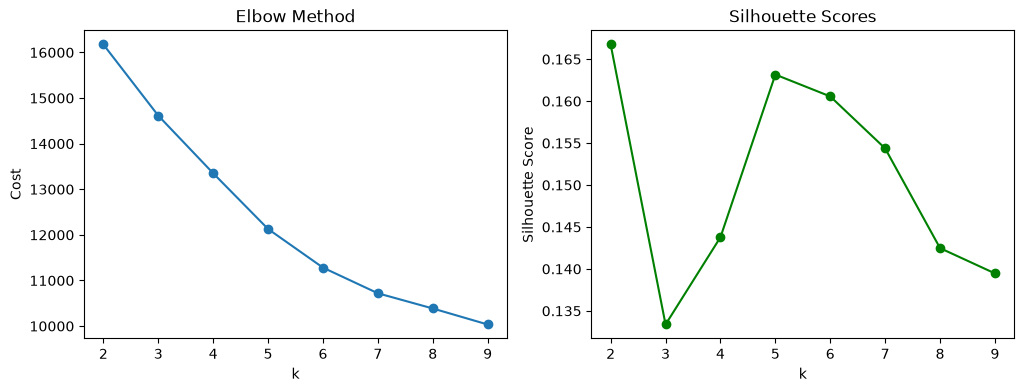

In [39]:
# Elbow Method & Silhouette Scores
inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kproto = KPrototypes(n_clusters=k, random_state=42, n_init=10)
    labels = kproto.fit_predict(X_scaled, categorical=categorical_indices)
    inertia.append(kproto.cost_)
    silhouette_scores.append(silhouette_score(X_scaled[:, :len(numerical_cols)].astype(float), labels))

# Plot Evaluation Metrics
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(K_range, inertia, marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Cost")

ax[1].plot(K_range, silhouette_scores, marker="o", color="green")
ax[1].set_title("Silhouette Scores")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette Score")
plt.show()

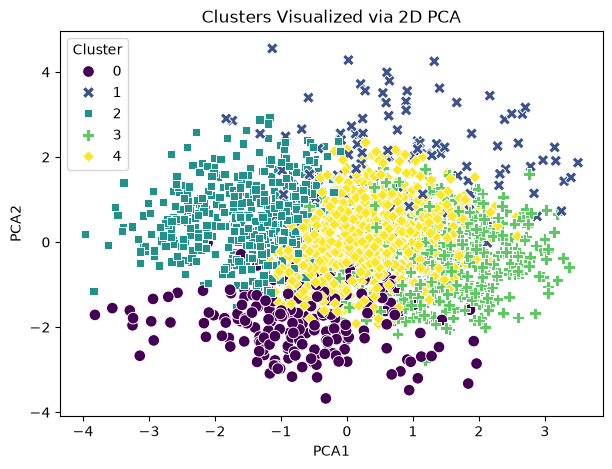

In [40]:
# Fit K-Prototypes with optimal k (e.g., k=4)
optimal_k = 5
kproto = KPrototypes(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kproto.fit_predict(X_scaled, categorical=categorical_indices)

# 6. PCA to 2D & Plot Scatter Plot (numerical features only, since PCA requires numeric input)
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled[:, :len(numerical_cols)].astype(float))

df["PCA1"] = pca_coords[:, 0]
df["PCA2"] = pca_coords[:, 1]

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="viridis",
    style="Cluster",
    s=70,
)
plt.title("Clusters Visualized via 2D PCA")
plt.show()

In [41]:
# Calculate Mean/Profile Characteristics Per Cluster
# Cluster size
cluster_size = df.groupby("Cluster").size().rename("cluster_size")

# Numerical averages
cluster_means = df.groupby("Cluster")[numerical_cols].mean()

# Categorical distributions (percentages/modes per cluster)
cat_profile = df.groupby("Cluster")[categorical_cols].agg(
    lambda x: x.mode()[0]
)

# Combine summary table
summary_df = pd.concat([cluster_size, cluster_means, cat_profile], axis=1)

print("\n--- Cluster Summary Profile ---")
print(summary_df)



--- Cluster Summary Profile ---
         cluster_size  child_aspiration_continue_farming  life_satisfaction  \
Cluster                                                                       
0                 234                           0.643447           2.269231   
1                 107                           3.227043           2.653147   
2                 507                           3.001012           2.290582   
3                 452                           3.110834           2.226361   
4                 794                           3.257993           2.102840   

         land_size_cropland_acres        age  years_of_schooling  \
Cluster                                                            
0                        3.194514  43.034188            6.487179   
1                       27.845926  50.177570            8.598131   
2                        3.423630  62.201183            2.757396   
3                        2.109650  41.853982            8.400442   
4    